In the previous notebook I explored the Rossmann sales data.
In this notebook I focus on feature engineering, model training and evaluation for the sales forecasting task.

In [55]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, learning_curve
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import optuna
from sklearn.metrics import root_mean_squared_error
import shap 


In [2]:
df_sales = pd.read_csv('../data/train.csv', low_memory=False)
df_store = pd.read_csv('../data/store.csv', low_memory=False)

In [3]:
def merge_store(df_store : pd.DataFrame, df_sales : pd.DataFrame) -> pd.DataFrame:
    df_store_copy = df_store.copy()
    df_sales_copy = df_sales.copy()
    df_sales_copy['Date'] = pd.to_datetime(df_sales_copy['Date'])
    df_full = pd.merge(df_store_copy, df_sales_copy, on='Store', how='left')
    return df_full 

df_full = merge_store(df_store, df_sales)

In [4]:
df_full = df_full[df_full['Open'] == 1]

In [5]:
df_full.info()
df_full.head()

<class 'pandas.DataFrame'>
Index: 844392 entries, 0 to 1017207
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844392 non-null  int64         
 1   StoreType                  844392 non-null  str           
 2   Assortment                 844392 non-null  str           
 3   CompetitionDistance        842206 non-null  float64       
 4   CompetitionOpenSinceMonth  575773 non-null  float64       
 5   CompetitionOpenSinceYear   575773 non-null  float64       
 6   Promo2                     844392 non-null  int64         
 7   Promo2SinceWeek            421085 non-null  float64       
 8   Promo2SinceYear            421085 non-null  float64       
 9   PromoInterval              421085 non-null  str           
 10  DayOfWeek                  844392 non-null  int64         
 11  Date                       844392 non-null  datetime64[us]
 12  Sal

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,5,2015-07-31,5263,555,1,1,0,1
1,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,4,2015-07-30,5020,546,1,1,0,1
2,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,3,2015-07-29,4782,523,1,1,0,1
3,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2,2015-07-28,5011,560,1,1,0,1
4,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,1,2015-07-27,6102,612,1,1,0,1


In [6]:
df_full = df_full.sort_values(['Date', 'Store'])

y = df_full['Sales'].copy() 
X = df_full.drop(columns=['Sales'])
y_log = np.log1p(y) 

In [7]:
X['Date'].head(3000)

77677    2013-01-01
235513   2013-01-01
238339   2013-01-01
249459   2013-01-01
305081   2013-01-01
            ...    
697074   2013-01-04
697832   2013-01-04
698774   2013-01-04
699716   2013-01-04
700658   2013-01-04
Name: Date, Length: 3000, dtype: datetime64[us]

In [8]:
X.info()

<class 'pandas.DataFrame'>
Index: 844392 entries, 77677 to 1016267
Data columns (total 17 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844392 non-null  int64         
 1   StoreType                  844392 non-null  str           
 2   Assortment                 844392 non-null  str           
 3   CompetitionDistance        842206 non-null  float64       
 4   CompetitionOpenSinceMonth  575773 non-null  float64       
 5   CompetitionOpenSinceYear   575773 non-null  float64       
 6   Promo2                     844392 non-null  int64         
 7   Promo2SinceWeek            421085 non-null  float64       
 8   Promo2SinceYear            421085 non-null  float64       
 9   PromoInterval              421085 non-null  str           
 10  DayOfWeek                  844392 non-null  int64         
 11  Date                       844392 non-null  datetime64[us]
 12 

In [9]:
print(X['Date'].min(), X['Date'].max())

2013-01-01 00:00:00 2015-07-31 00:00:00


In [10]:
split_date = '2015-04-01'

mask_train = df_full['Date'] < split_date
mask_test = df_full['Date'] >= split_date

X_train = X[mask_train]
X_test = X[mask_test]
y_train = y_log[mask_train]
y_test = y_log[mask_test]

In [11]:
print(f'Train dataset shape: {X_train.shape}')
print(f'Test dataset shape: {X_test.shape}')

Train dataset shape: (732970, 17)
Test dataset shape: (111422, 17)


In [12]:
print(y_train.shape, y_test.shape)

(732970,) (111422,)


In [13]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 732970 entries, 77677 to 1016389
Data columns (total 17 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      732970 non-null  int64         
 1   StoreType                  732970 non-null  str           
 2   Assortment                 732970 non-null  str           
 3   CompetitionDistance        731083 non-null  float64       
 4   CompetitionOpenSinceMonth  499719 non-null  float64       
 5   CompetitionOpenSinceYear   499719 non-null  float64       
 6   Promo2                     732970 non-null  int64         
 7   Promo2SinceWeek            364285 non-null  float64       
 8   Promo2SinceYear            364285 non-null  float64       
 9   PromoInterval              364285 non-null  str           
 10  DayOfWeek                  732970 non-null  int64         
 11  Date                       732970 non-null  datetime64[us]
 12 

In [14]:
X_train['StateHoliday'].value_counts()

StateHoliday
0    732281
a       522
b        96
c        71
Name: count, dtype: int64

In [15]:
X_train['DayOfWeek'].value_counts()

DayOfWeek
6    125113
2    125019
3    121881
1    120781
5    120775
4    116355
7      3046
Name: count, dtype: int64

In [16]:
class FeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.store_median_sales_ = None 
        self.store_promo_median_sales_ = None 
        self.store_dow_median_sales_ = None 

    def fit(self, X, y=None):
        if y is not None: 
            temp_df = pd.DataFrame({'Store': X['Store'], 'LogSales': y})
            self.store_median_sales_ = temp_df.groupby('Store')['LogSales'].median().to_dict()
            self.store_promo_median_sales_ = temp_df.join(X['Promo']).groupby(['Store', 'Promo'])['LogSales'].median().to_dict()
            self.store_dow_median_sales_ = temp_df.join(X['DayOfWeek']).groupby(['Store', 'DayOfWeek'])['LogSales'].median().to_dict()
        return self 
    
    def _has_competition(self, X):
        has_comp = (~X["CompetitionOpenSinceYear"].isna()) & (~X["CompetitionOpenSinceMonth"].isna())
        X["HasCompetition"] = has_comp.astype(int)
        
    
    def _calculate_months_since_competition(self, X):
        X["CompetitionOpenSinceYear_filled"] = X["CompetitionOpenSinceYear"].fillna(X["Date"].dt.year).astype(int)
        X["CompetitionOpenSinceMonth_filled"] = X["CompetitionOpenSinceMonth"].fillna(X["Date"].dt.month).astype(int)
        date_year = X["Date"].dt.year
        date_month = X["Date"].dt.month
        start_year = X["CompetitionOpenSinceYear_filled"]
        start_month = X["CompetitionOpenSinceMonth_filled"]
        X["MonthsSinceCompetition"] = (date_year - start_year) * 12 + (date_month - start_month)
        X.loc[X["HasCompetition"] == 0, "MonthsSinceCompetition"] = 0
        X["MonthsSinceCompetition"] = X["MonthsSinceCompetition"].clip(lower=0)
        
    
    def _calculate_months_since_promo2(self, X):
        has_promo2 = (
        (X["Promo2"] == 1)
        & (~X["Promo2SinceYear"].isna())
        & (~X["Promo2SinceWeek"].isna()))

        X["Promo2SinceYear_filled"] = X["Promo2SinceYear"].fillna(X["Date"].dt.isocalendar().year).astype(int)
        X["Promo2SinceWeek_filled"] = X["Promo2SinceWeek"].fillna(X["Date"].dt.isocalendar().week).astype(int)
        promo2_start_str = (
            X["Promo2SinceYear_filled"].astype(str)
            + X["Promo2SinceWeek_filled"].astype(str).str.zfill(2)
            + "1")
        X["Promo2StartDate"] = pd.to_datetime(
            promo2_start_str,
            format="%G%V%u",
            errors="coerce"
        )
        start_year = X["Promo2StartDate"].dt.year
        start_month = X["Promo2StartDate"].dt.month
        date_year = X["Date"].dt.year
        date_month = X["Date"].dt.month

        X["months_since_promo2"] = (date_year - start_year) * 12 + (
            date_month - start_month
        )
        X.loc[~has_promo2, "months_since_promo2"] = 0
        X["months_since_promo2"] = X["months_since_promo2"].fillna(0).clip(lower=0)
        

    
    def transform(self, X):
        X_copy = X.copy()
        X_copy['Year'] = X_copy['Date'].dt.year
        X_copy['Month'] = X_copy['Date'].dt.month
        X_copy['WeekOfYear'] = X_copy['Date'].dt.isocalendar().week.astype(int)
        X_copy['IsWeekend'] = np.where((X_copy['DayOfWeek'] == 6) | (X_copy['DayOfWeek'] == 7), 1, 0)
        self._has_competition(X_copy)
        self._calculate_months_since_competition(X_copy)
        self._calculate_months_since_promo2(X_copy)
        X_copy['Promo_SchoolHoliday_interaction'] = X_copy['Promo'] * X_copy['SchoolHoliday']
        X_copy['Promo_DayOfWeek_interaction'] = X_copy['Promo'] * X_copy['DayOfWeek']
        X_copy['PromoInterval'] = X_copy['PromoInterval'].str.replace(',', '_')
        if self.store_median_sales_ is not None:
            default_val = np.mean(list(self.store_median_sales_.values()))
            X_copy['StoreMedianLogSales'] = X_copy['Store'].map(self.store_median_sales_).fillna(default_val)
            pair_store_promo = list(zip(X_copy['Store'], X_copy['Promo']))
            X_copy['StorePromoMedianLogSales'] = [self.store_promo_median_sales_.get(pt, default_val) for pt in pair_store_promo]
            pair_store_dow = list(zip(X_copy['Store'], X_copy['DayOfWeek']))
            X_copy['StoreDowMedianLogSales'] = [self.store_dow_median_sales_.get(pt, default_val) for pt in pair_store_dow]
        else:
            X_copy['StoreMedianLogSales'] = 0.0
            X_copy['StorePromoMedianLogSales'] = 0.0
            X_copy['StoreDowMedianLogSales'] = 0.0
        X_copy = X_copy.drop(columns=[
            "Date",
            "CompetitionOpenSinceMonth",
            "CompetitionOpenSinceYear",
            "Promo2SinceWeek",
            "Promo2SinceYear",
            "CompetitionOpenSinceYear_filled",
            "CompetitionOpenSinceMonth_filled",
            "Promo2SinceYear_filled",
            "Promo2SinceWeek_filled",
            "Promo2StartDate",  
            "Customers"])
        return X_copy

In [17]:
ft = FeatureTransformer()
X_val = ft.transform(X_train)
X_val.info()

<class 'pandas.DataFrame'>
Index: 732970 entries, 77677 to 1016389
Data columns (total 23 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Store                            732970 non-null  int64  
 1   StoreType                        732970 non-null  str    
 2   Assortment                       732970 non-null  str    
 3   CompetitionDistance              731083 non-null  float64
 4   Promo2                           732970 non-null  int64  
 5   PromoInterval                    364285 non-null  str    
 6   DayOfWeek                        732970 non-null  int64  
 7   Open                             732970 non-null  int64  
 8   Promo                            732970 non-null  int64  
 9   StateHoliday                     732970 non-null  str    
 10  SchoolHoliday                    732970 non-null  int64  
 11  Year                             732970 non-null  int32  
 12  Month        

In [18]:
X_val.head()

,Store,StoreType,Assortment,CompetitionDistance,Promo2,PromoInterval,DayOfWeek,Open,Promo,StateHoliday,...,WeekOfYear,IsWeekend,HasCompetition,MonthsSinceCompetition,months_since_promo2,Promo_SchoolHoliday_interaction,Promo_DayOfWeek_interaction,StoreMedianLogSales,StorePromoMedianLogSales,StoreDowMedianLogSales
77677,85,b,a,1870.0,0,NaN,2,1,0,a,...,1,0,1,15,0,0,0,0.0,0.0,0.0
235513,259,b,b,210.0,0,NaN,2,1,0,a,...,1,0,0,0,0,0,0,0.0,0.0,0.0
238339,262,b,a,1180.0,0,NaN,2,1,0,a,...,1,0,1,0,0,0,0,0.0,0.0,0.0
249459,274,b,b,3640.0,1,Jan_Apr_Jul_Oct,2,1,0,a,...,1,0,0,0,0,0,0,0.0,0.0,0.0
305081,335,b,a,90.0,1,Jan_Apr_Jul_Oct,2,1,0,a,...,1,0,0,0,0,0,0,0.0,0.0,0.0


In [19]:
cols = ['Year', 'Month', 'WeekOfYear', 'IsWeekend', 'HasCompetition', 'MonthsSinceCompetition', 'months_since_promo2', 'Promo_SchoolHoliday_interaction', 'Promo_DayOfWeek_interaction']

for col in cols:
    print(f'\n{X_val[col].value_counts()}')


Year
2013    337943
2014    310417
2015     84610
Name: count, dtype: int64

Month
1     86343
3     85980
2     80243
7     55399
4     54800
8     54413
5     54223
6     54153
10    53292
9     52330
11    51401
12    50393
Name: count, dtype: int64

WeekOfYear
12    20099
9     20093
11    20081
6     20068
5     20065
8     20053
10    20051
4     20047
3     20043
7     20041
2     19448
13    19007
1     15161
14    14551
20    13419
26    13403
15    13400
23    13400
25    12733
27    12496
42    12361
43    12361
41    12360
39    12356
51    12355
38    12338
34    12336
19    12334
21    12334
45    12334
48    12334
49    12334
46    12333
50    12333
32    12332
31    12331
24    12328
28    12323
30    12322
17    12321
37    12321
35    12318
16    12308
29    12305
36    12300
33    12194
47    12182
22    11649
18    11228
44    11042
40    10385
52     8319
Name: count, dtype: int64

IsWeekend
0    604811
1    128159
Name: count, dtype: int64

HasCompetition
1    49

In [20]:
X_val.info()

<class 'pandas.DataFrame'>
Index: 732970 entries, 77677 to 1016389
Data columns (total 23 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Store                            732970 non-null  int64  
 1   StoreType                        732970 non-null  str    
 2   Assortment                       732970 non-null  str    
 3   CompetitionDistance              731083 non-null  float64
 4   Promo2                           732970 non-null  int64  
 5   PromoInterval                    364285 non-null  str    
 6   DayOfWeek                        732970 non-null  int64  
 7   Open                             732970 non-null  int64  
 8   Promo                            732970 non-null  int64  
 9   StateHoliday                     732970 non-null  str    
 10  SchoolHoliday                    732970 non-null  int64  
 11  Year                             732970 non-null  int32  
 12  Month        

In [21]:
X_val['StoreType'].value_counts()

StoreType
a    397049
d    224176
c     98256
b     13489
Name: count, dtype: int64

In [22]:
X_val['Assortment'].value_counts()

Assortment
a    385869
c    339987
b      7114
Name: count, dtype: int64

In [23]:
X_val['Promo2'].value_counts() 

Promo2
0    368685
1    364285
Name: count, dtype: int64

In [24]:
print(X_val['CompetitionDistance'].min(), X_val['CompetitionDistance'].max())

20.0 75860.0


In [25]:
X_val['PromoInterval'].value_counts()

PromoInterval
Jan_Apr_Jul_Oct     209056
Feb_May_Aug_Nov      85118
Mar_Jun_Sept_Dec     70111
Name: count, dtype: int64

In [26]:
X_val['DayOfWeek'].value_counts()

DayOfWeek
6    125113
2    125019
3    121881
1    120781
5    120775
4    116355
7      3046
Name: count, dtype: int64

In [27]:
X_val['Open'].value_counts()

Open
1    732970
Name: count, dtype: int64

In [28]:
X_val['Promo'].value_counts()

Promo
0    406678
1    326292
Name: count, dtype: int64

In [29]:
X_val['SchoolHoliday'].value_counts()

SchoolHoliday
0    592957
1    140013
Name: count, dtype: int64

In [30]:
X_val['WeekOfYear'].value_counts()

WeekOfYear
12    20099
9     20093
11    20081
6     20068
5     20065
8     20053
10    20051
4     20047
3     20043
7     20041
2     19448
13    19007
1     15161
14    14551
20    13419
26    13403
15    13400
23    13400
25    12733
27    12496
42    12361
43    12361
41    12360
39    12356
51    12355
38    12338
34    12336
19    12334
21    12334
45    12334
48    12334
49    12334
46    12333
50    12333
32    12332
31    12331
24    12328
28    12323
30    12322
17    12321
37    12321
35    12318
16    12308
29    12305
36    12300
33    12194
47    12182
22    11649
18    11228
44    11042
40    10385
52     8319
Name: count, dtype: int64

In [31]:
X_val['MonthsSinceCompetition'].value_counts()

MonthsSinceCompetition
0       305987
4         4987
5         4875
6         4784
7         4702
         ...  
619         23
1360        23
632         23
1373        23
191         23
Name: count, Length: 316, dtype: int64

In [32]:
X_val['Promo_SchoolHoliday_interaction'].value_counts()

Promo_SchoolHoliday_interaction
0    667513
1     65457
Name: count, dtype: int64

In [33]:
X_test.isna().mean().sort_values(ascending=False)

Promo2SinceWeek              0.490226
PromoInterval                0.490226
Promo2SinceYear              0.490226
CompetitionOpenSinceYear     0.317424
CompetitionOpenSinceMonth    0.317424
CompetitionDistance          0.002683
Store                        0.000000
StoreType                    0.000000
Assortment                   0.000000
Promo2                       0.000000
DayOfWeek                    0.000000
Date                         0.000000
Customers                    0.000000
Open                         0.000000
Promo                        0.000000
StateHoliday                 0.000000
SchoolHoliday                0.000000
dtype: float64

In [34]:
X_val.isna().mean().sort_values(ascending=False)

PromoInterval                      0.503001
CompetitionDistance                0.002574
Store                              0.000000
Assortment                         0.000000
StoreType                          0.000000
Promo2                             0.000000
DayOfWeek                          0.000000
Open                               0.000000
Promo                              0.000000
StateHoliday                       0.000000
SchoolHoliday                      0.000000
Year                               0.000000
Month                              0.000000
WeekOfYear                         0.000000
IsWeekend                          0.000000
HasCompetition                     0.000000
MonthsSinceCompetition             0.000000
months_since_promo2                0.000000
Promo_SchoolHoliday_interaction    0.000000
Promo_DayOfWeek_interaction        0.000000
StoreMedianLogSales                0.000000
StorePromoMedianLogSales           0.000000
StoreDowMedianLogSales          

In [35]:
cols_for_ohe = ['StoreType', 'Assortment', 'PromoInterval', 'StateHoliday']
cols_for_scaling = ['CompetitionDistance', 'MonthsSinceCompetition', 'months_since_promo2']
cols_for_passthorugh = [
    'Year', 'Store', 'Month', 'Promo2', 'DayOfWeek', 'Open', 'Promo', 
    'SchoolHoliday', 'WeekOfYear', 'IsWeekend', 'HasCompetition',
    'Promo_SchoolHoliday_interaction', 'Promo_DayOfWeek_interaction',
    'StoreMedianLogSales', 'StorePromoMedianLogSales', 'StoreDowMedianLogSales'
]

In [36]:
ohe_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'), 
    OneHotEncoder(handle_unknown='ignore')
)

num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'), 
    StandardScaler()
)

num_passtrough_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent')
)

preprocessor = ColumnTransformer([
    ('ohe_pipeline', ohe_pipeline, cols_for_ohe),
    ('num_pipeline', num_pipeline, cols_for_scaling),
    ('num_passtrough_pipeline', num_passtrough_pipeline, cols_for_passthorugh)
])

In [37]:
decison_tree_reg_pipeline = Pipeline([
    ('feature_transformer', FeatureTransformer()),
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=30))
])

In [38]:
tscv = TimeSeriesSplit(n_splits=5, gap=1115)

scores = cross_val_score(decison_tree_reg_pipeline, 
                         X_train, y_train, 
                         cv=tscv, 
                         scoring='neg_root_mean_squared_error', 
                         n_jobs=-1)

rmse_scores = -scores
print(rmse_scores.mean(), rmse_scores.std())

0.2672748955271347 0.03333882932462429


In [39]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=decison_tree_reg_pipeline,
    X=X_train,
    y=y_train,
    cv=tscv,
    scoring='neg_root_mean_squared_error', 
    train_sizes=np.linspace(0.1, 1.0, 5), 
    n_jobs=-1
)
train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

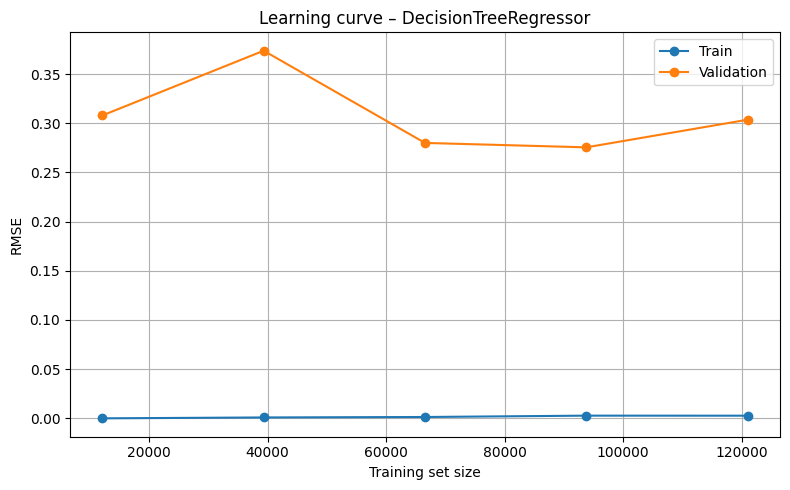

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(train_sizes, train_rmse, marker="o", label="Train")
plt.plot(train_sizes, val_rmse, marker="o", label="Validation")

plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.title("Learning curve – DecisionTreeRegressor")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [41]:
rf_pipeline = Pipeline([
    ('feature_transformer', FeatureTransformer()),
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=300, min_samples_leaf=10, n_jobs=-1, random_state=42))
])

scores = cross_val_score(rf_pipeline, 
                         X_train, y_train, 
                         cv=tscv, 
                         scoring='neg_root_mean_squared_error', 
                         n_jobs=-1)

rmse_scores = -scores
print(rmse_scores.mean(), rmse_scores.std())

0.19792786276091187 0.02606427622913183


/home/szymon/projects/rossman_forecasting/env/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/szymon/projects/rossman_forecasting/env/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/szymon/projects/rossman_forecasting/env/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn

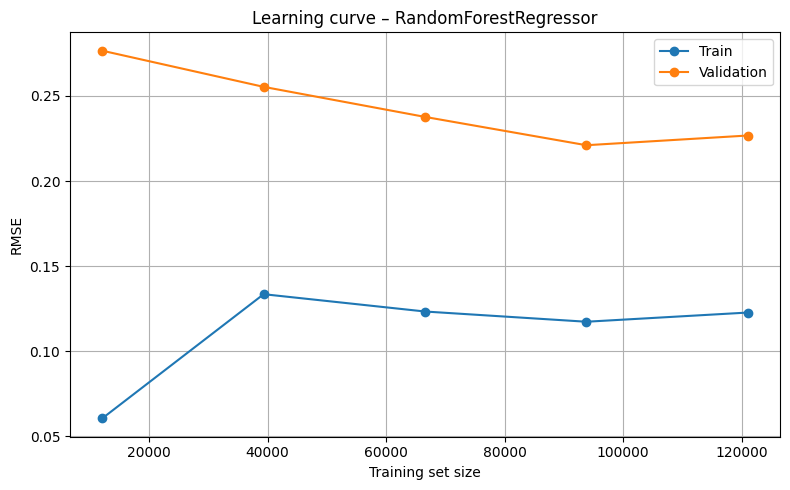

In [42]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=rf_pipeline,
    X=X_train,
    y=y_train,
    cv=tscv,
    scoring='neg_root_mean_squared_error', 
    train_sizes=np.linspace(0.1, 1.0, 5), 
    n_jobs=-1
)
train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, marker="o", label="Train")
plt.plot(train_sizes, val_rmse, marker="o", label="Validation")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.title("Learning curve – RandomForestRegressor")
plt.legend()
plt.grid() 
plt.tight_layout()
plt.show()

In [43]:
xgb_pipeline = Pipeline([
    ('feature_transformer', FeatureTransformer()), 
    ('preprocessor', preprocessor), 
    ('xgb_model', XGBRegressor())
])

scores = cross_val_score(xgb_pipeline, X_train, y_train, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)

rmse_scores = -scores
print(rmse_scores.mean(), rmse_scores.std())

0.20860907832230552 0.03559294603325032


/home/szymon/projects/rossman_forecasting/env/lib64/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


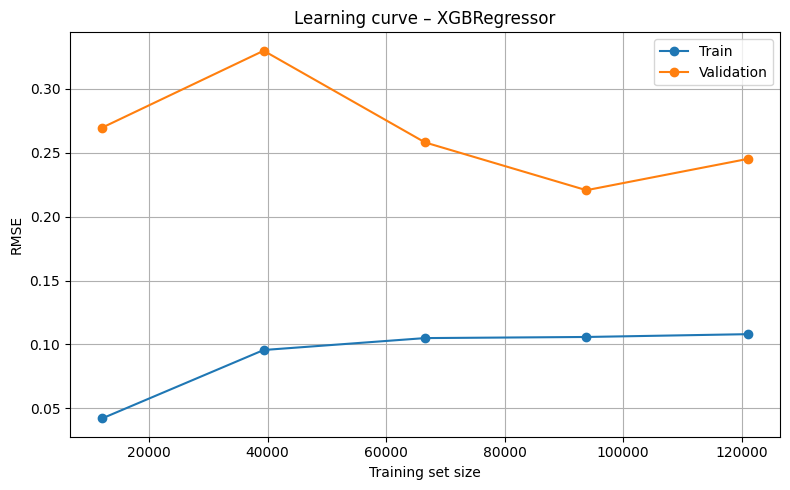

In [44]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=xgb_pipeline,
    X=X_train,
    y=y_train,
    cv=tscv,
    scoring='neg_root_mean_squared_error', 
    train_sizes=np.linspace(0.1, 1.0, 5), 
    n_jobs=-1
)
train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, marker="o", label="Train")
plt.plot(train_sizes, val_rmse, marker="o", label="Validation")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.title("Learning curve – XGBRegressor")
plt.legend()
plt.grid() 
plt.tight_layout()
plt.show()

In [45]:
def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 1e-3, 10.0, log=True)
    }
    model = XGBRegressor(**params, random_state=42)
    xgb_optuna_pipeline = Pipeline([
        ('feature_transformer', FeatureTransformer()), 
        ('preprocessor', preprocessor), 
        ('model', model)
    ])
    scores = cross_val_score(xgb_optuna_pipeline, 
                             X_train, 
                             y_train, 
                             cv=tscv, 
                             scoring='neg_root_mean_squared_error', 
                             n_jobs=-1)
    rmse_scores = -scores 
    return np.mean(rmse_scores)

study_name = 'xgb_reg-tuning'
study = optuna.create_study(
    study_name=study_name,
    direction='minimize'
)
study.optimize(objective, n_trials=30) 
print(f'Best RMSE score: {study.best_value}')

[I 2026-05-22 19:29:10,626] A new study created in memory with name: xgb_reg-tuning
[I 2026-05-22 19:29:27,859] Trial 0 finished with value: 0.21413025430269136 and parameters: {'max_depth': 3, 'learning_rate': 0.0042847933384033985, 'n_estimators': 415, 'subsample': 0.9657962505312545, 'colsample_bytree': 0.8256990062796203, 'min_child_weight': 6, 'reg_alpha': 0.95854199547724, 'reg_lambda': 0.0015446677384242274, 'gamma': 0.43934166904374894}. Best is trial 0 with value: 0.21413025430269136.
[I 2026-05-22 19:29:43,726] Trial 1 finished with value: 0.228041981958422 and parameters: {'max_depth': 5, 'learning_rate': 0.004983074926129389, 'n_estimators': 246, 'subsample': 0.7742587329883753, 'colsample_bytree': 0.6019008595949713, 'min_child_weight': 13, 'reg_alpha': 2.9813600057674314, 'reg_lambda': 0.7407031056394799, 'gamma': 0.003574355483345075}. Best is trial 0 with value: 0.21413025430269136.
[I 2026-05-22 19:30:24,373] Trial 2 finished with value: 0.2759929544987801 and paramete

Best RMSE score: 0.19438898112127895


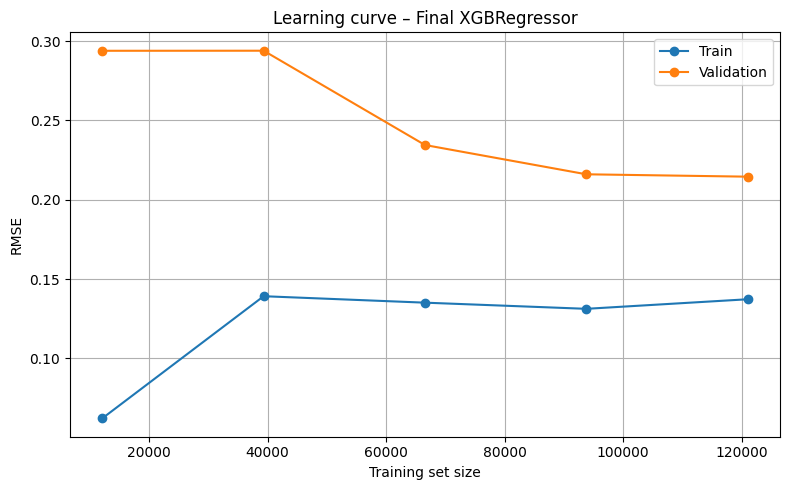

In [46]:
best_params = study.best_params

final_xgb_pipeline = Pipeline([
    ('feature_transformer', FeatureTransformer()), 
    ('preprocessor', preprocessor), 
    ('best_xgb_model', XGBRegressor(**best_params, random_state=42))
])

train_sizes, train_scores, val_scores = learning_curve(
    estimator=final_xgb_pipeline,
    X=X_train,
    y=y_train,
    cv=tscv,
    scoring='neg_root_mean_squared_error', 
    train_sizes=np.linspace(0.1, 1.0, 5), 
    n_jobs=-1
)
train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, marker="o", label="Train")
plt.plot(train_sizes, val_rmse, marker="o", label="Validation")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.title("Learning curve – Final XGBRegressor")
plt.legend()
plt.grid() 
plt.tight_layout()
plt.show()

In [ ]:
final_xgb_pipeline.fit(X_train, y_train)
y_pred = final_xgb_pipeline.predict(X_test) 
test_rmse = root_mean_squared_error(y_test, y_pred)
print(f'Test RMSE: {test_rmse:.2f}')    

Test RMSE: 0.15


In [49]:
y_pred_original = np.expm1(final_xgb_pipeline.predict(X_test))
y_test_original = np.expm1(y_test)
test_rmse_original = root_mean_squared_error(y_test_original, y_pred_original)
print(f'Test RMSE (oryginalna skala): {test_rmse_original:.2f}')

Test RMSE (oryginalna skala): 1144.97


In [52]:
def rmspe(y_true, y_pred):
    mask = y_true > 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true) ** 2))

print(f'RMSPE: {rmspe(y_test_original, y_pred_original):.4f}')

RMSPE: 0.1473


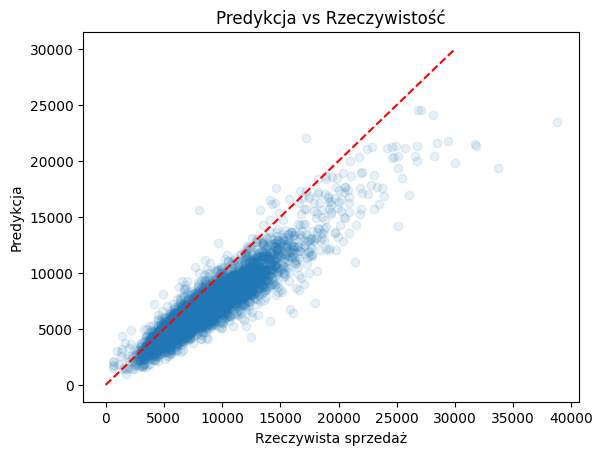

In [51]:
plt.scatter(y_test_original[:5000], y_pred_original[:5000], alpha=0.1)
plt.plot([0, 30000], [0, 30000], 'r--')
plt.xlabel('Rzeczywista sprzedaż')
plt.ylabel('Predykcja')
plt.title('Predykcja vs Rzeczywistość')
plt.show()

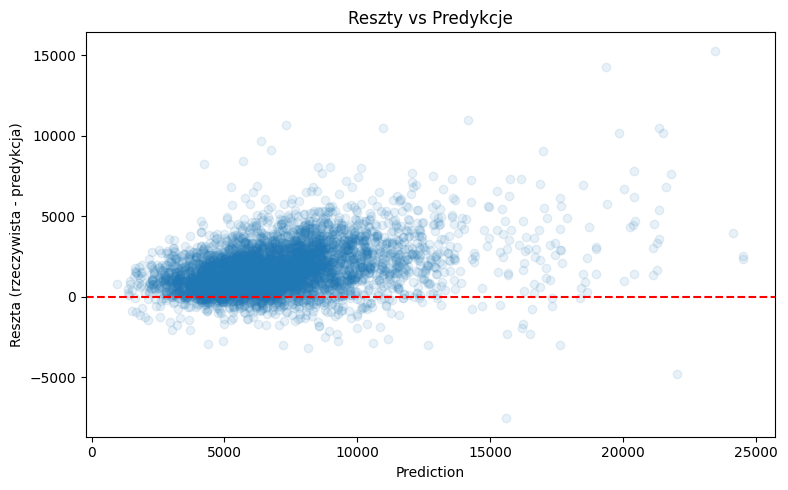

In [53]:
residuals = y_test_original - y_pred_original

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_original[:5000], residuals[:5000], alpha=0.1)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Prediction')
plt.ylabel('Reszta (rzeczywista - predykcja)')
plt.title('Reszty vs Predykcje')
plt.tight_layout()
plt.show()

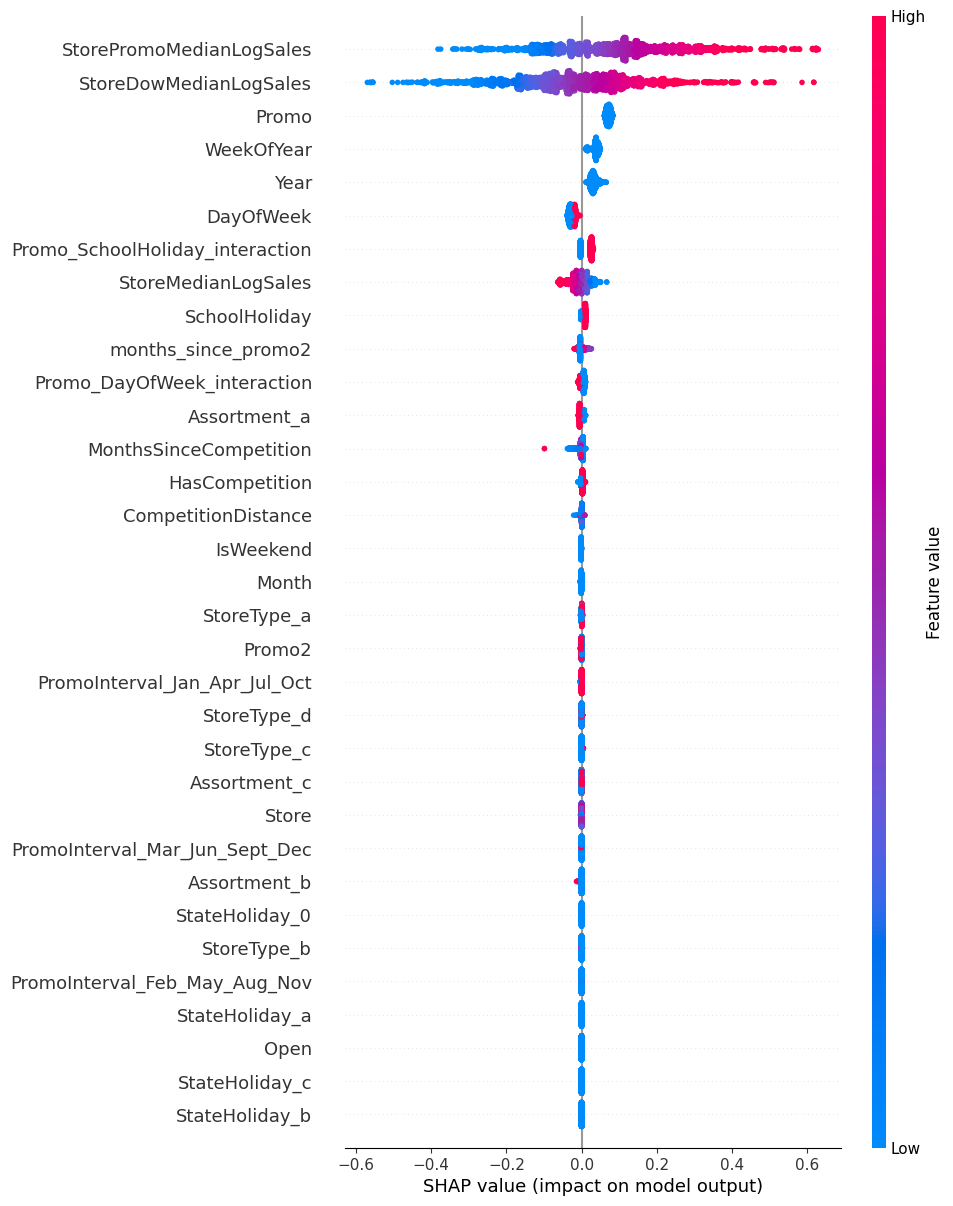

In [ ]:
import shap

ohe_features = (final_xgb_pipeline
    .named_steps['preprocessor']
    .named_transformers_['ohe_pipeline']
    .named_steps['onehotencoder']
    .get_feature_names_out(cols_for_ohe)
    .tolist())

all_feature_names = ohe_features + cols_for_scaling + cols_for_passthorugh
X_test_transformed = final_xgb_pipeline[:-1].transform(X_test)
X_test_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)
explainer = shap.TreeExplainer(final_xgb_pipeline.named_steps['best_xgb_model'])
shap_values = explainer(X_test_df[:2000])
shap.plots.beeswarm(shap_values, max_display=len(all_feature_names))

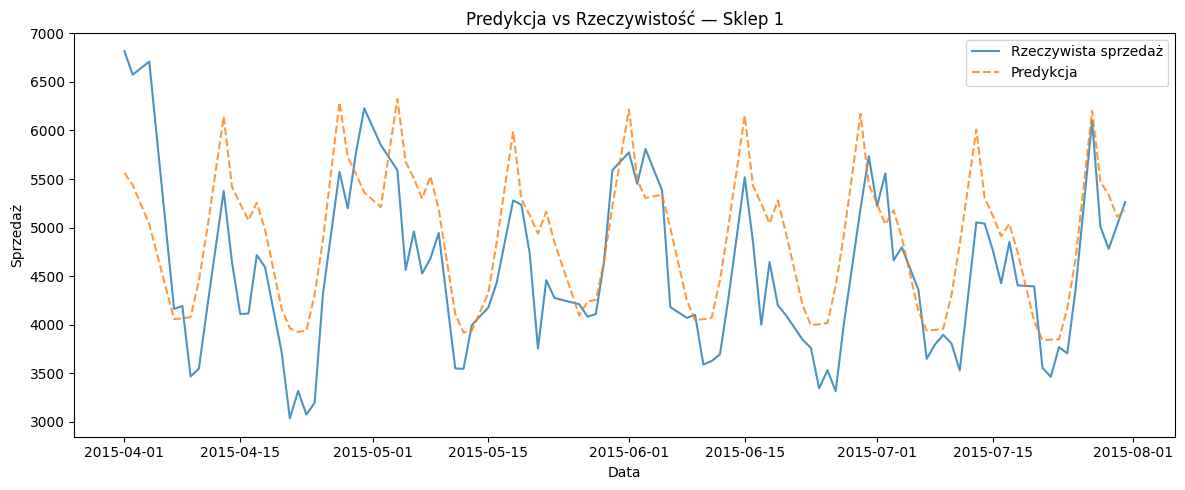

In [58]:
store_id = 1  # możesz zmienić na dowolny

mask = X_test['Store'] == store_id
y_pred_store = y_pred_original[mask.values]
y_true_store = y_test_original[mask.values]
dates_store = df_full[mask_test & (df_full['Store'] == store_id)]['Date']

plt.figure(figsize=(12, 5))
plt.plot(dates_store.values, y_true_store, label='Rzeczywista sprzedaż', alpha=0.8)
plt.plot(dates_store.values, y_pred_store, label='Predykcja', alpha=0.8, linestyle='--')
plt.xlabel('Data')
plt.ylabel('Sprzedaż')
plt.title(f'Predykcja vs Rzeczywistość — Sklep {store_id}')
plt.legend()
plt.tight_layout()
plt.show()

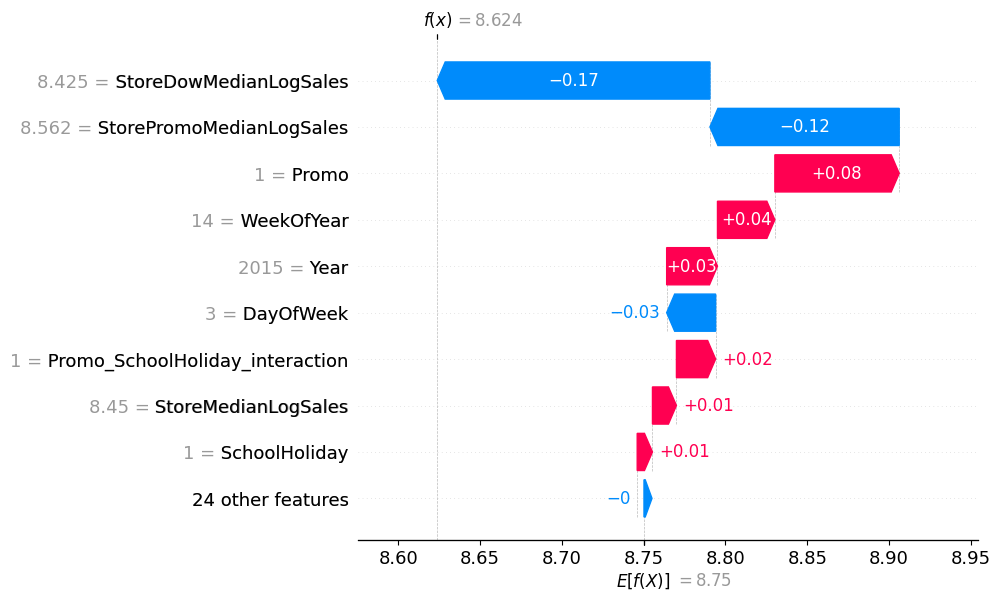

In [ ]:
idx = mask.values.nonzero()[0][0]
shap.plots.waterfall(shap_values[idx])